In [1]:
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import (
    VGG16, VGG19, ResNet50, EfficientNetB0
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger
from tensorflow.keras.optimizers import SGD

from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, precision_recall_fscore_support
)
sns.set_style('whitegrid')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.15.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Set seed for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"✅ Random seed set to {SEED}")

✅ Random seed set to 42


## 2. Configuration

In [ ]:
# ============================================
# CONFIGURATION
# ============================================

DATASET_NAME = 'MangoLeafBD'

# ⚠️ CHANGE THIS TO SELECT BACKBONE
# Options: 'vgg16', 'vgg19', 'resnet50', 'efficientnetb0'
BACKBONE_NAME = 'resnet50'

# Model name will be derived from backbone
MODEL_NAME = f'{BACKBONE_NAME.upper()}_Pretrained'

# Image size and training parameters
IMG_SIZE = 227  # Common size for all backbones
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.001

# Two-phase training parameters
PHASE1_EPOCHS = 20  # Head-only training
FINE_TUNE_LR = LEARNING_RATE / 10  # 0.0001 for fine-tuning

# Paths
WORKSPACE_DIR = Path('/Users/invictus/Desktop/Thesis project/thesis_draft')
DATA_DIR = WORKSPACE_DIR / 'datasets' / DATASET_NAME / 'processed'
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR = DATA_DIR / 'val'
TEST_DIR = DATA_DIR / 'test'

# Output directories
EXPERIMENTS_BASE = WORKSPACE_DIR / DATASET_NAME / 'experiments' / MODEL_NAME
OUTPUTS_BASE = WORKSPACE_DIR / DATASET_NAME / 'outputs' / MODEL_NAME

def get_next_run_dir(parent_dir, prefix='run_'):
    parent_dir = Path(parent_dir)
    parent_dir.mkdir(parents=True, exist_ok=True)
    existing = [d for d in parent_dir.iterdir() if d.is_dir() and d.name.startswith(prefix)]
    nums = [int(d.name[len(prefix):]) for d in existing if d.name[len(prefix):].isdigit()]
    next_num = max(nums) + 1 if nums else 1
    return parent_dir / f'{prefix}{next_num}'

EXPERIMENT_DIR = get_next_run_dir(EXPERIMENTS_BASE)
OUTPUT_DIR = get_next_run_dir(OUTPUTS_BASE)
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("="*60)
print("📁 CONFIGURATION")
print("="*60)
print(f"Dataset        : {DATASET_NAME}")
print(f"Backbone       : {BACKBONE_NAME}")
print(f"Model          : {MODEL_NAME}")
print(f"Input Size     : {IMG_SIZE}×{IMG_SIZE}")
print(f"Batch Size     : {BATCH_SIZE}")
print(f"Total Epochs   : {EPOCHS}")
print(f"Phase 1 Epochs : {PHASE1_EPOCHS} (head-only)")
print(f"Phase 2 Epochs : {EPOCHS - PHASE1_EPOCHS} (fine-tuning)")
print(f"Preprocessing  : ImageNet normalization (mean/std)")
print(f"Optimizer      : SGD (Phase1 lr={LEARNING_RATE}, Phase2 lr={FINE_TUNE_LR}, momentum=0.9)")
print(f"Experiment Dir : {EXPERIMENT_DIR}")
print(f"Output Dir     : {OUTPUT_DIR}")
print("="*60)

📁 CONFIGURATION
Dataset        : MangoLeafBD
Backbone       : resnet50
Model          : RESNET50_Pretrained
Input Size     : 227×227
Batch Size     : 32
Total Epochs   : 100
Phase 1 Epochs : 20 (head-only)
Phase 2 Epochs : 80 (fine-tuning)
Preprocessing  : ImageNet normalization (mean/std)
Optimizer      : SGD (Phase1 lr=0.001, Phase2 lr=0.0001, momentum=0.9)
Experiment Dir : /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/experiments/RESNET50_Pretrained/run_1
Output Dir     : /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/RESNET50_Pretrained/run_1


## 3. Data Loading

Using ImageNet normalization (mean subtraction + std division) for all pretrained backbones.

In [4]:
# ============================================
# PREPROCESSING & DATA GENERATORS
# ============================================

# ImageNet statistics
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def imagenet_preprocess(image):
    """Normalize image using ImageNet mean and std"""
    image = image / 255.0  # Scale to [0, 1]
    image = (image - IMAGENET_MEAN) / IMAGENET_STD  # Normalize
    return image

# Training with MODERATE augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=imagenet_preprocess,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation & Test - only normalize, no augmentation
val_test_datagen = ImageDataGenerator(
    preprocessing_function=imagenet_preprocess
)

train_generator = train_datagen.flow_from_directory(
    str(TRAIN_DIR),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_directory(
    str(VAL_DIR),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    str(TEST_DIR),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

n_classes = len(train_generator.class_indices)
class_names = list(train_generator.class_indices.keys())

print(f"\n✅ Data loaded successfully!")
print(f"   Classes: {n_classes}")
print(f"   Training: {train_generator.samples} images")
print(f"   Validation: {val_generator.samples} images")
print(f"   Test: {test_generator.samples} images")

# Save class names
with open(EXPERIMENT_DIR / 'classes.json', 'w') as f:
    json.dump(class_names, f, indent=2)

Found 3200 images belonging to 8 classes.
Found 400 images belonging to 8 classes.
Found 400 images belonging to 8 classes.

✅ Data loaded successfully!
   Classes: 8
   Training: 3200 images
   Validation: 400 images
   Test: 400 images
Found 400 images belonging to 8 classes.
Found 400 images belonging to 8 classes.

✅ Data loaded successfully!
   Classes: 8
   Training: 3200 images
   Validation: 400 images
   Test: 400 images


## 4. Build Model

Common pretrained model builder supporting multiple backbones:
- VGG16
- VGG19
- ResNet50
- EfficientNetB0

All backbones share the same classification head architecture.

In [5]:
# ============================================
# BACKBONE AND MODEL BUILDER FUNCTIONS
# ============================================

def get_backbone_class(name: str):
    """
    Returns the Keras backbone class for the given name.
    
    Args:
        name: One of 'vgg16', 'vgg19', 'resnet50', 'efficientnetb0'
    
    Returns:
        Keras Application class
    """
    backbones = {
        'vgg16': VGG16,
        'vgg19': VGG19,
        'resnet50': ResNet50,
        'efficientnetb0': EfficientNetB0,
    }
    
    name_lower = name.lower()
    if name_lower not in backbones:
        raise ValueError(f"Unknown backbone '{name}'. Supported: {list(backbones.keys())}")
    
    return backbones[name_lower]


def get_fine_tune_config(name: str, base_model):
    """
    Returns fine-tuning configuration for each backbone.
    Specifies how many layers to unfreeze from the top.
    
    Args:
        name: Backbone name
        base_model: The loaded base model
    
    Returns:
        fine_tune_at: Index from which to start unfreezing (layers before this are frozen)
    """
    total_layers = len(base_model.layers)
    
    # Configuration for each backbone - unfreeze only the top block
    configs = {
        # VGG16: Unfreeze last conv block (block5) - approximately last 4 conv layers
        'vgg16': total_layers - 4,
        
        # VGG19: Unfreeze last conv block (block5) - approximately last 4 conv layers
        'vgg19': total_layers - 4,
        
        # ResNet50: Unfreeze conv5_x block - approximately last 38 layers
        'resnet50': total_layers - 38,
        
        # EfficientNetB0: Unfreeze last few MBConv blocks - approximately last 30 layers
        'efficientnetb0': total_layers - 30,
    }
    
    name_lower = name.lower()
    if name_lower not in configs:
        # Default: unfreeze top 20% of layers
        return int(total_layers * 0.8)
    
    return configs[name_lower]


def build_pretrained_model(backbone_name: str, num_classes: int, input_shape=(227, 227, 3)):
    """
    Builds a pretrained model with a common classification head.
    
    Args:
        backbone_name: One of 'vgg16', 'vgg19', 'resnet50', 'efficientnetb0'
        num_classes: Number of output classes
        input_shape: Input image shape, default (227, 227, 3)
    
    Returns:
        Compiled Keras model
    """
    # Get backbone class
    Backbone = get_backbone_class(backbone_name)
    
    # Load backbone with ImageNet weights
    base_model = Backbone(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )
    
    # Initially freeze the base model for Phase 1 (head-only training)
    base_model.trainable = False
    
    # Build model with common classification head
    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs, name=f'{backbone_name}_mango')
    
    # Compile for Phase 1 training
    optimizer = SGD(learning_rate=LEARNING_RATE, momentum=0.9)
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model, base_model


print("✅ Model builder functions defined")
print(f"   Supported backbones: vgg16, vgg19, resnet50, efficientnetb0")

✅ Model builder functions defined
   Supported backbones: vgg16, vgg19, resnet50, efficientnetb0


In [6]:
# ============================================
# BUILD MODEL WITH SELECTED BACKBONE
# ============================================

print(f"\n🔧 Building model with backbone: {BACKBONE_NAME}")

model, base_model = build_pretrained_model(
    backbone_name=BACKBONE_NAME,
    num_classes=n_classes,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

print(f"\n✅ Model built successfully!")
print(f"   Backbone: {BACKBONE_NAME}")
print(f"   Input shape: ({IMG_SIZE}, {IMG_SIZE}, 3)")
print(f"   Output classes: {n_classes}")
print(f"   Total params: {model.count_params():,}")
print(f"   Base model layers: {len(base_model.layers)}")
print(f"   Base model trainable: {base_model.trainable}")

trainable_params = sum([tf.reduce_prod(w.shape).numpy() for w in model.trainable_weights])
print(f"   Trainable params (Phase 1): {trainable_params:,}")

model.summary()


🔧 Building model with backbone: resnet50


2025-12-02 03:28:49.347107: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-12-02 03:28:49.347139: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-12-02 03:28:49.347145: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2025-12-02 03:28:49.347171: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-02 03:28:49.347183: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



✅ Model built successfully!
   Backbone: resnet50
   Input shape: (227, 227, 3)
   Output classes: 8
   Total params: 24,640,904
   Base model layers: 175
   Base model trainable: False
   Trainable params (Phase 1): 1,053,192
Model: "resnet50_mango"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 227, 227, 3)]     0         
                                                                 
 resnet50 (Functional)       (None, 8, 8, 2048)        23587712  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 512)               1049088   
                                                                 
 dropout (Dropout)    

## 5. Compile & Train

Two-phase training strategy:
1. **Phase 1 (Epochs 1-20)**: Train only the classification head with frozen backbone
2. **Phase 2 (Epochs 21-100)**: Fine-tune the top layers of the backbone with lower learning rate

In [7]:
# ============================================
# CALLBACKS
# ============================================

model_path = EXPERIMENT_DIR / f'{MODEL_NAME}_{DATASET_NAME}_best.h5'

callbacks = [
    ModelCheckpoint(
        filepath=str(model_path),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    CSVLogger(EXPERIMENT_DIR / 'training_log.csv')
]

print("✅ Callbacks configured")
print(f"   Model checkpoint: {model_path}")
print(f"   CSV Logger: {EXPERIMENT_DIR / 'training_log.csv'}")

✅ Callbacks configured
   Model checkpoint: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/experiments/RESNET50_Pretrained/run_1/RESNET50_Pretrained_MangoLeafBD_best.h5
   CSV Logger: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/experiments/RESNET50_Pretrained/run_1/training_log.csv


In [8]:
# ============================================
# PHASE 1: HEAD-ONLY TRAINING
# ============================================

print("\n" + "="*60)
print("🚀 PHASE 1: HEAD-ONLY TRAINING")
print("="*60)
print(f"   Epochs: 1-{PHASE1_EPOCHS}")
print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   Backbone frozen: True")
print("="*60)

# Ensure base model is frozen for Phase 1
base_model.trainable = False

# Model is already compiled with LEARNING_RATE from build_pretrained_model
history_stage1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=PHASE1_EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print(f"\n✅ Phase 1 complete!")
print(f"   Best val_accuracy: {max(history_stage1.history['val_accuracy']):.4f}")


🚀 PHASE 1: HEAD-ONLY TRAINING
   Epochs: 1-20
   Learning Rate: 0.001
   Backbone frozen: True
Epoch 1/20


2025-12-02 03:28:51.051927: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2025-12-02 03:28:51.097670: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node SGD/AssignVariableOp.


100/100 [==============================] - ETA: 0s - loss: 2.0741 - accuracy: 0.2453
Epoch 1: val_accuracy improved from -inf to 0.53250, saving model to /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/experiments/RESNET50_Pretrained/run_1/RESNET50_Pretrained_MangoLeafBD_best.h5

Epoch 1: val_accuracy improved from -inf to 0.53250, saving model to /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/experiments/RESNET50_Pretrained/run_1/RESNET50_Pretrained_MangoLeafBD_best.h5
100/100 [==============================] - 22s 208ms/step - loss: 2.0741 - accuracy: 0.2453 - val_loss: 1.5472 - val_accuracy: 0.5325
Epoch 2/20
100/100 [==============================] - 22s 208ms/step - loss: 2.0741 - accuracy: 0.2453 - val_loss: 1.5472 - val_accuracy: 0.5325
Epoch 2/20


/Users/invictus/tf-metal-311/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


100/100 [==============================] - ETA: 0s - loss: 1.5895 - accuracy: 0.4050
Epoch 2: val_accuracy did not improve from 0.53250
100/100 [==============================] - 21s 206ms/step - loss: 1.5895 - accuracy: 0.4050 - val_loss: 1.3550 - val_accuracy: 0.5050
Epoch 3/20

Epoch 2: val_accuracy did not improve from 0.53250
100/100 [==============================] - 21s 206ms/step - loss: 1.5895 - accuracy: 0.4050 - val_loss: 1.3550 - val_accuracy: 0.5050
Epoch 3/20
100/100 [==============================] - ETA: 0s - loss: 1.4138 - accuracy: 0.4666
Epoch 3: val_accuracy improved from 0.53250 to 0.56250, saving model to /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/experiments/RESNET50_Pretrained/run_1/RESNET50_Pretrained_MangoLeafBD_best.h5

Epoch 3: val_accuracy improved from 0.53250 to 0.56250, saving model to /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/experiments/RESNET50_Pretrained/run_1/RESNET50_Pretrained_MangoLeafBD_best.h5
100/100 

In [9]:
# ============================================
# PHASE 2: FINE-TUNING
# ============================================

print("\n" + "="*60)
print("🔓 PHASE 2: FINE-TUNING")
print("="*60)

# Unfreeze the top block of the backbone
base_model.trainable = True
fine_tune_at = get_fine_tune_config(BACKBONE_NAME, base_model)

# Freeze all layers before fine_tune_at
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"   Total layers in backbone: {len(base_model.layers)}")
print(f"   Frozen layers: {fine_tune_at}")
print(f"   Unfrozen layers: {len(base_model.layers) - fine_tune_at}")

trainable_params = sum([tf.reduce_prod(w.shape).numpy() for w in model.trainable_weights])
print(f"   Trainable params (Phase 2): {trainable_params:,}")

# Recompile with lower learning rate
optimizer = SGD(learning_rate=FINE_TUNE_LR, momentum=0.9)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\n   Epochs: {PHASE1_EPOCHS + 1}-{EPOCHS}")
print(f"   Learning Rate: {FINE_TUNE_LR}")
print("="*60)

# Continue training from where Phase 1 left off
history_stage2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    initial_epoch=PHASE1_EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print(f"\n✅ Phase 2 complete!")
print(f"   Best val_accuracy: {max(history_stage2.history['val_accuracy']):.4f}")


🔓 PHASE 2: FINE-TUNING
   Total layers in backbone: 175
   Frozen layers: 137
   Unfrozen layers: 38
   Trainable params (Phase 2): 16,294,920

   Epochs: 21-100
   Learning Rate: 0.0001
Epoch 21/100
Epoch 21/100


2025-12-02 03:37:30.849669: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node SGD/AssignVariableOp.


100/100 [==============================] - ETA: 0s - loss: 0.8482 - accuracy: 0.6844
Epoch 21: val_accuracy improved from 0.75250 to 0.77000, saving model to /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/experiments/RESNET50_Pretrained/run_1/RESNET50_Pretrained_MangoLeafBD_best.h5

Epoch 21: val_accuracy improved from 0.75250 to 0.77000, saving model to /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/experiments/RESNET50_Pretrained/run_1/RESNET50_Pretrained_MangoLeafBD_best.h5
100/100 [==============================] - 30s 282ms/step - loss: 0.8482 - accuracy: 0.6844 - val_loss: 0.6339 - val_accuracy: 0.7700
Epoch 22/100
100/100 [==============================] - 30s 282ms/step - loss: 0.8482 - accuracy: 0.6844 - val_loss: 0.6339 - val_accuracy: 0.7700
Epoch 22/100
100/100 [==============================] - ETA: 0s - loss: 0.7703 - accuracy: 0.7184
Epoch 22: val_accuracy improved from 0.77000 to 0.79500, saving model to /Users/invictus/Desktop/Thesis p

In [10]:
# ============================================
# COMBINE TRAINING HISTORIES
# ============================================

# Combine histories from both phases
history_dict = {
    'accuracy': [float(x) for x in history_stage1.history['accuracy']] + 
                [float(x) for x in history_stage2.history['accuracy']],
    'val_accuracy': [float(x) for x in history_stage1.history['val_accuracy']] + 
                    [float(x) for x in history_stage2.history['val_accuracy']],
    'loss': [float(x) for x in history_stage1.history['loss']] + 
            [float(x) for x in history_stage2.history['loss']],
    'val_loss': [float(x) for x in history_stage1.history['val_loss']] + 
                [float(x) for x in history_stage2.history['val_loss']]
}

# Create a combined history object for compatibility with plotting code
class CombinedHistory:
    def __init__(self, history_dict):
        self.history = history_dict

history = CombinedHistory(history_dict)

with open(EXPERIMENT_DIR / 'history.json', 'w') as f:
    json.dump(history_dict, f, indent=2)

print(f"✅ Combined training history saved")
print(f"   Total epochs trained: {len(history_dict['accuracy'])}")
print(f"   Phase 1 epochs: {PHASE1_EPOCHS}")
print(f"   Phase 2 epochs: {len(history_dict['accuracy']) - PHASE1_EPOCHS}")
print(f"   File: {EXPERIMENT_DIR / 'history.json'}")

✅ Combined training history saved
   Total epochs trained: 100
   Phase 1 epochs: 20
   Phase 2 epochs: 80
   File: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/experiments/RESNET50_Pretrained/run_1/history.json


## 6. Evaluation

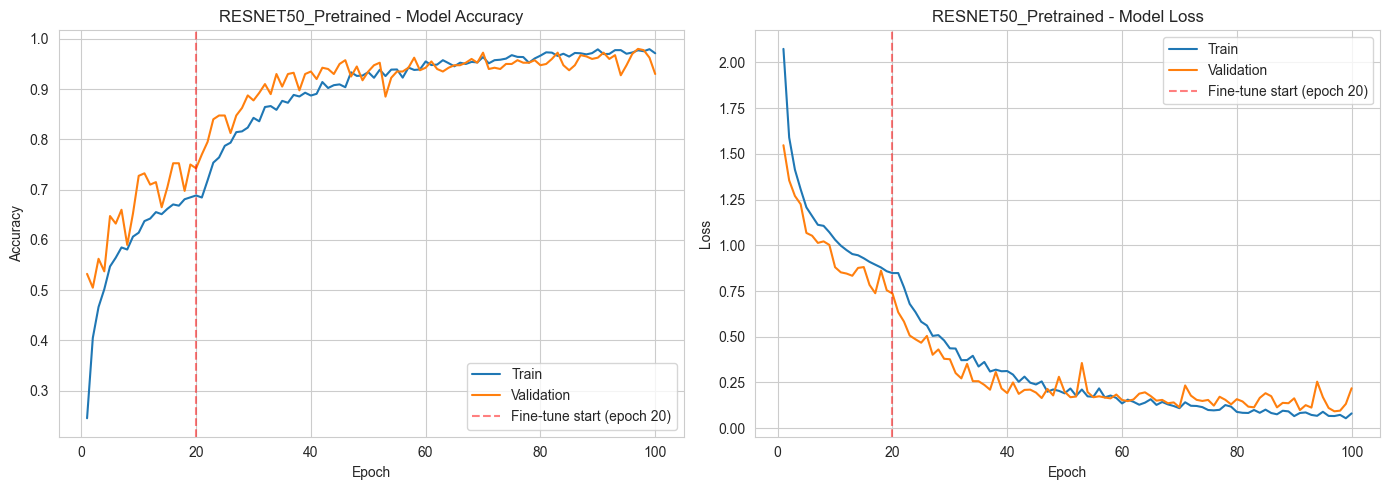

✅ Training history plot saved


In [11]:
# ============================================
# PLOT TRAINING HISTORY
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history.history['accuracy']) + 1)

# Accuracy
axes[0].plot(epochs_range, history.history['accuracy'], label='Train')
axes[0].plot(epochs_range, history.history['val_accuracy'], label='Validation')
axes[0].axvline(x=PHASE1_EPOCHS, color='r', linestyle='--', alpha=0.5, label=f'Fine-tune start (epoch {PHASE1_EPOCHS})')
axes[0].set_title(f'{MODEL_NAME} - Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(epochs_range, history.history['loss'], label='Train')
axes[1].plot(epochs_range, history.history['val_loss'], label='Validation')
axes[1].axvline(x=PHASE1_EPOCHS, color='r', linestyle='--', alpha=0.5, label=f'Fine-tune start (epoch {PHASE1_EPOCHS})')
axes[1].set_title(f'{MODEL_NAME} - Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Training history plot saved")

In [12]:
# ============================================
# EVALUATE ON TEST SET
# ============================================

print("\n" + "="*60)
print("📊 EVALUATING ON TEST SET")
print("="*60)

# Load best model
best_model = keras.models.load_model(str(model_path))

# Evaluate
test_loss, test_acc = best_model.evaluate(test_generator, verbose=1)

print(f"\n📈 Test Results:")
print(f"   Loss: {test_loss:.4f}")
print(f"   Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")


📊 EVALUATING ON TEST SET


13/13 [==============================] - 3s 177ms/step - loss: 0.1536 - accuracy: 0.9500

📈 Test Results:
   Loss: 0.1536
   Accuracy: 0.9500 (95.00%)
13/13 [==============================] - 3s 177ms/step - loss: 0.1536 - accuracy: 0.9500

📈 Test Results:
   Loss: 0.1536
   Accuracy: 0.9500 (95.00%)


13/13 [==============================] - 3s 182ms/step

📋 CLASSIFICATION REPORT
                  precision    recall  f1-score   support

     Anthracnose     0.9375    0.9000    0.9184        50
Bacterial Canker     0.9800    0.9800    0.9800        50
  Cutting Weevil     1.0000    1.0000    1.0000        50
        Die Back     1.0000    0.9600    0.9796        50
      Gall Midge     0.9074    0.9800    0.9423        50
         Healthy     0.9412    0.9600    0.9505        50
  Powdery Mildew     0.8772    1.0000    0.9346        50
     Sooty Mould     0.9762    0.8200    0.8913        50

        accuracy                         0.9500       400
       macro avg     0.9524    0.9500    0.9496       400
    weighted avg     0.9524    0.9500    0.9496       400


📋 CLASSIFICATION REPORT
                  precision    recall  f1-score   support

     Anthracnose     0.9375    0.9000    0.9184        50
Bacterial Canker     0.9800    0.9800    0.9800        50
  Cutting Weevil     

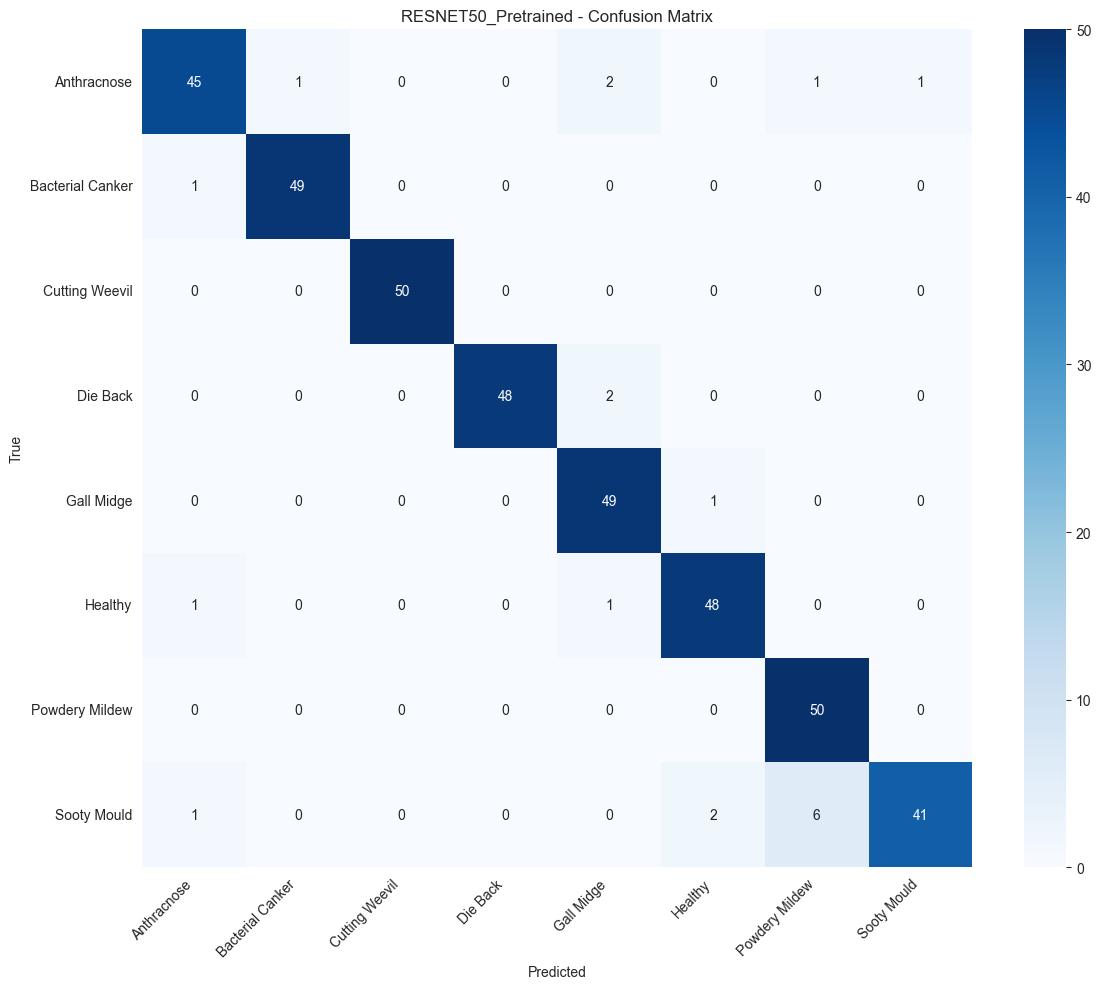


✅ Confusion matrix saved


In [13]:
# ============================================
# CLASSIFICATION REPORT & CONFUSION MATRIX
# ============================================

# Get predictions
test_generator.reset()
y_pred_probs = best_model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("\n" + "="*60)
print("📋 CLASSIFICATION REPORT")
print("="*60)
print(report)

# Save report
with open(OUTPUT_DIR / 'classification_report.txt', 'w') as f:
    f.write(report)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'{MODEL_NAME} - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Confusion matrix saved")

In [14]:
# ============================================
# FINAL EVALUATION SUMMARY
# ============================================

# Calculate overall metrics
overall_accuracy = accuracy_score(y_true, y_pred)
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro'
)
weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'
)

# Find best epoch based on validation accuracy
best_epoch = np.argmax(history.history['val_accuracy'])

# Get model parameter counts
total_params = model.count_params()
trainable_params_count = sum([tf.reduce_prod(w.shape).numpy() for w in model.trainable_weights])

# Create summary
summary = f"""
{'='*80}
              {MODEL_NAME} - FINAL EVALUATION SUMMARY
{'='*80}

DATASET INFORMATION:
  • Dataset Name          : {DATASET_NAME}
  • Number of Classes     : {n_classes}
  • Classes               : {', '.join(class_names)}
  • Training Samples      : {train_generator.samples}
  • Validation Samples    : {val_generator.samples}
  • Test Samples          : {test_generator.samples}

MODEL ARCHITECTURE:
  • Backbone              : {BACKBONE_NAME}
  • Model Name            : {MODEL_NAME}
  • Input Size            : {IMG_SIZE}x{IMG_SIZE}x3
  • Total Parameters      : {total_params:,}
  • Trainable Parameters  : {trainable_params_count:,}

TRAINING CONFIGURATION:
  • Optimizer             : SGD (momentum=0.9)
  • Phase 1 Learning Rate : {LEARNING_RATE}
  • Phase 2 Learning Rate : {FINE_TUNE_LR}
  • Batch Size            : {BATCH_SIZE}
  • Total Epochs          : {EPOCHS}
  • Phase 1 (Head-only)   : {PHASE1_EPOCHS} epochs
  • Phase 2 (Fine-tuning) : {EPOCHS - PHASE1_EPOCHS} epochs
  • Epochs Trained        : {len(history.history['loss'])}

PREPROCESSING:
  • Type                  : ImageNet Normalization (mean/std)
  • Augmentation          : Rotation(15°), Shift(0.1), Zoom(0.1), Horizontal Flip

TEST SET PERFORMANCE:
  • Overall Accuracy      : {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)
  
  Macro Average:
    - Precision           : {macro_precision:.4f}
    - Recall              : {macro_recall:.4f}
    - F1-Score            : {macro_f1:.4f}
  
  Weighted Average:
    - Precision           : {weighted_precision:.4f}
    - Recall              : {weighted_recall:.4f}
    - F1-Score            : {weighted_f1:.4f}

BEST EPOCH METRICS (Validation):
  • Best Epoch            : {best_epoch + 1}/{len(history.history['loss'])}
  • Training Loss         : {history.history['loss'][best_epoch]:.4f}
  • Training Accuracy     : {history.history['accuracy'][best_epoch]:.4f}
  • Validation Loss       : {history.history['val_loss'][best_epoch]:.4f}
  • Validation Accuracy   : {history.history['val_accuracy'][best_epoch]:.4f}

OUTPUT FILES:
  • Model                 : {model_path}
  • Classes JSON          : {EXPERIMENT_DIR / 'classes.json'}
  • Training History      : {EXPERIMENT_DIR / 'history.json'}
  • Model Info            : {EXPERIMENT_DIR / 'model_info.json'}
  • Classification Report : {OUTPUT_DIR / 'classification_report.txt'}
  • Confusion Matrix      : {OUTPUT_DIR / 'confusion_matrix.png'}
  • Training History Plot : {OUTPUT_DIR / 'training_history.png'}

{'='*80}
"""

print(summary)

# Save summary to file
with open(OUTPUT_DIR / 'evaluation_summary.txt', 'w') as f:
    f.write(summary)

print(f"\n✅ Evaluation summary saved to: {OUTPUT_DIR / 'evaluation_summary.txt'}")


              RESNET50_Pretrained - FINAL EVALUATION SUMMARY

DATASET INFORMATION:
  • Dataset Name          : MangoLeafBD
  • Number of Classes     : 8
  • Classes               : Anthracnose, Bacterial Canker, Cutting Weevil, Die Back, Gall Midge, Healthy, Powdery Mildew, Sooty Mould
  • Training Samples      : 3200
  • Validation Samples    : 400
  • Test Samples          : 400

MODEL ARCHITECTURE:
  • Backbone              : resnet50
  • Model Name            : RESNET50_Pretrained
  • Input Size            : 227x227x3
  • Total Parameters      : 24,640,904
  • Trainable Parameters  : 16,294,920

TRAINING CONFIGURATION:
  • Optimizer             : SGD (momentum=0.9)
  • Phase 1 Learning Rate : 0.001
  • Phase 2 Learning Rate : 0.0001
  • Batch Size            : 32
  • Total Epochs          : 100
  • Phase 1 (Head-only)   : 20 epochs
  • Phase 2 (Fine-tuning) : 80 epochs
  • Epochs Trained        : 100

PREPROCESSING:
  • Type                  : ImageNet Normalization (mean/std)
  •

## 7. Summary

In [15]:
# ============================================
# FINAL SUMMARY
# ============================================

# Save model info
model_info = {
    'model_name': MODEL_NAME,
    'backbone': BACKBONE_NAME,
    'dataset': DATASET_NAME,
    'input_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'total_epochs': EPOCHS,
    'phase1_epochs': PHASE1_EPOCHS,
    'phase2_epochs': EPOCHS - PHASE1_EPOCHS,
    'epochs_trained': len(history.history['accuracy']),
    'optimizer': f'SGD (Phase1: lr={LEARNING_RATE}, Phase2: lr={FINE_TUNE_LR}, momentum=0.9)',
    'preprocessing': 'ImageNet normalization (mean/std)',
    'test_accuracy': float(test_acc),
    'test_loss': float(test_loss),
    'total_params': model.count_params(),
    'n_classes': n_classes,
    'class_names': class_names,
    'training_strategy': 'Two-phase: head-only + fine-tuning'
}

with open(EXPERIMENT_DIR / 'model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

print("\n" + "="*60)
print("🏁 FINAL SUMMARY")
print("="*60)
print(f"Backbone       : {BACKBONE_NAME}")
print(f"Model          : {MODEL_NAME}")
print(f"Dataset        : {DATASET_NAME}")
print(f"Input Size     : {IMG_SIZE}×{IMG_SIZE}")
print(f"Preprocessing  : ImageNet normalization")
print(f"Training       : Two-phase (head-only + fine-tuning)")
print(f"Phase 1        : {PHASE1_EPOCHS} epochs, lr={LEARNING_RATE}")
print(f"Phase 2        : {len(history.history['accuracy']) - PHASE1_EPOCHS} epochs, lr={FINE_TUNE_LR}")
print(f"Epochs Trained : {len(history.history['accuracy'])}")
print(f"Test Accuracy  : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Loss      : {test_loss:.4f}")
print("="*60)
print(f"✅ Model saved : {model_path}")
print(f"✅ History     : {EXPERIMENT_DIR / 'history.json'}")
print(f"✅ Model Info  : {EXPERIMENT_DIR / 'model_info.json'}")
print("="*60)
print("🎉 TRAINING COMPLETE!")


🏁 FINAL SUMMARY
Backbone       : resnet50
Model          : RESNET50_Pretrained
Dataset        : MangoLeafBD
Input Size     : 227×227
Preprocessing  : ImageNet normalization
Training       : Two-phase (head-only + fine-tuning)
Phase 1        : 20 epochs, lr=0.001
Phase 2        : 80 epochs, lr=0.0001
Epochs Trained : 100
Test Accuracy  : 0.9500 (95.00%)
Test Loss      : 0.1536
✅ Model saved : /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/experiments/RESNET50_Pretrained/run_1/RESNET50_Pretrained_MangoLeafBD_best.h5
✅ History     : /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/experiments/RESNET50_Pretrained/run_1/history.json
✅ Model Info  : /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/experiments/RESNET50_Pretrained/run_1/model_info.json
🎉 TRAINING COMPLETE!
